# IT3212 Assignment 2 - Blob detection (15 points)

We implement a multiscale Laplacian-of-Gaussian (LoG) detector, apply it to a fixed sample from the
vehicle-type dataset, visualize detections, report their positions and sizes, and investigate parameters.
The algorithm finds locally contrasting image regions, **not semantic vehicle instances**.

Run all cells from a fresh Python kernel with the repository requirements installed. Outputs are saved
under `figures/assignment2/blob_detection/`; numerical results go to the gitignored
`results/assignment2/blob_detection/`. The contour notebook uses the same image manifest.

In [4]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from PIL import Image, ImageOps
from scipy.ndimage import gaussian_filter, gaussian_laplace, maximum_filter
from IPython.display import display, Markdown
import scipy
import PIL

REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / "AGENTS.md").is_file() and (p / "notebooks").is_dir()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Run from within the IT3212 repository.")
DATA_DIR = REPO_ROOT / "data" / "vehicle-type-detection"
FIGURE_DIR = REPO_ROOT / "figures" / "assignment2" / "blob_detection"
RESULT_DIR = REPO_ROOT / "results" / "assignment2" / "blob_detection"
if not DATA_DIR.is_dir():
    raise FileNotFoundError(DATA_DIR)
for directory in [FIGURE_DIR, RESULT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
print(f"Python {sys.version.split()[0]}, NumPy {np.__version__}, SciPy {scipy.__version__}, Pillow {PIL.__version__}")

Python 3.13.7, NumPy 2.5.2, SciPy 1.18.1, Pillow 12.3.0


## 1. Dataset and fixed sample

The supplied local dataset has five vehicle-type folders. Its original source/Blackboard attribution
must still be recorded before submission. The inventory below is computed from the actual files.
`detection_images.json` selects two images per class (10 total) by sorted filename. This is a small,
reproducible qualitative sample, not a random or representative evaluation of all 1,310 images.
Both detection notebooks must use this same manifest when comparing their results.

Folder labels identify vehicle types; they do not annotate blob locations or boundaries, so they cannot
be used to calculate blob precision or recall.

In [5]:
extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
inventory = pd.DataFrame([
    {"class": d.name, "images": sum(p.suffix.lower() in extensions for p in d.rglob("*") if p.is_file())}
    for d in sorted(DATA_DIR.iterdir()) if d.is_dir()
])
display(inventory)
print("Total images:", inventory["images"].sum())
manifest_path = REPO_ROOT / "notebooks" / "assignment2" / "detection_images.json"
image_ids = json.loads(manifest_path.read_text(encoding="utf-8"))
assert image_ids and len(image_ids) == len(set(image_ids))
for image_id in image_ids:
    if not (DATA_DIR / image_id).is_file():
        raise FileNotFoundError(DATA_DIR / image_id)

,class,images
0,hatchback,181
1,motorcycle,122
2,pickup,478
3,sedan,400
4,suv,129


Total images: 1310


## 2. Image preparation

Apply EXIF orientation, convert to RGB for display and grayscale for detection, and divide grayscale
intensities by 255 to obtain `[0, 1]`. Limit the longest side to 512 pixels with aspect ratio preserved;
do not enlarge small images. This bounds computation without forcing different shapes into a square.
The table records the actual dimensions and resize factors. Pixels do not have a common physical size
across these photographs, so equal radii do not imply equal physical objects.

We retain intensity contrast without histogram equalization. Gaussian smoothing is already part of LoG;
additional smoothing is zero in the baseline and tested separately. Coordinates use the top-left origin:
`x` increases to the right and `y` downwards. All plotted circles and primary measurements refer to the
processed image. Original-coordinate columns refer to the EXIF-oriented image.

,image,original_width,original_height,width,height,scale_x,scale_y
0,hatchback/PIC_0.jpg,136,173,136,173,1.000000,1.000000
1,hatchback/PIC_1.jpg,597,420,512,360,0.857621,0.857143
2,motorcycle/PIC_0.jpg,301,514,300,512,0.996678,0.996109
3,motorcycle/PIC_10.jpg,92,162,92,162,1.000000,1.000000
4,pickup/PIC_0.jpg,313,241,313,241,1.000000,1.000000
5,pickup/PIC_1.jpg,353,224,353,224,1.000000,1.000000
6,sedan/PIC_0.jpg,196,155,196,155,1.000000,1.000000
7,sedan/PIC_1.jpg,552,351,512,326,0.927536,0.928775
8,suv/PIC_0.jpg,509,338,509,338,1.000000,1.000000
9,suv/PIC_1.jpg,309,249,309,249,1.000000,1.000000


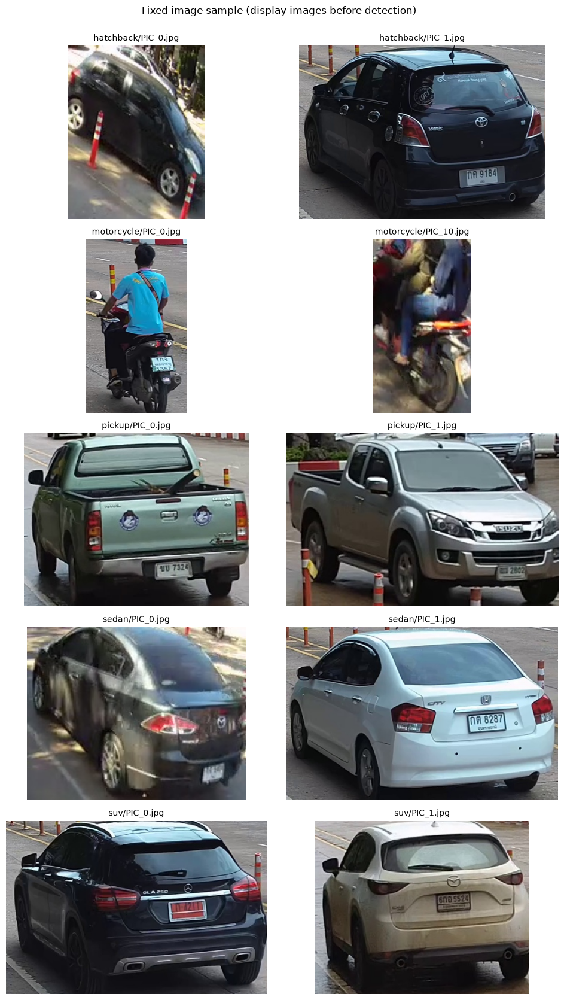

In [6]:
MAX_SIDE = 512
records = {}
for image_id in image_ids:
    with Image.open(DATA_DIR / image_id) as source:
        rgb_image = ImageOps.exif_transpose(source).convert("RGB")
    original_width, original_height = rgb_image.size
    factor = min(1.0, MAX_SIDE / max(rgb_image.size))
    size = (max(1, round(original_width * factor)), max(1, round(original_height * factor)))
    if size != rgb_image.size:
        rgb_image = rgb_image.resize(size, Image.Resampling.LANCZOS)
    gray = np.asarray(rgb_image.convert("L"), dtype=np.float64) / 255.0
    assert gray.ndim == 2 and np.isfinite(gray).all() and 0 <= gray.min() <= gray.max() <= 1
    records[image_id] = dict(rgb=np.asarray(rgb_image), gray=gray,
                            original_width=original_width, original_height=original_height,
                            width=size[0], height=size[1],
                            scale_x=size[0] / original_width, scale_y=size[1] / original_height)
image_info = pd.DataFrame([
    dict(image=image_id, **{k: v for k, v in record.items() if k not in {"rgb", "gray"}})
    for image_id, record in records.items()
])
display(image_info)

fig, axes = plt.subplots(5, 2, figsize=(10, 17))
for ax, (image_id, record) in zip(axes.flat, records.items()):
    ax.imshow(record["rgb"])
    ax.set_title(image_id, fontsize=10)
    ax.axis("off")
fig.suptitle("Fixed image sample (display images before detection)")
fig.tight_layout(rect=(0, 0, 1, 0.98))
fig.savefig(FIGURE_DIR / "01_original_images.png", dpi=140)
plt.show()
plt.close(fig)

## 3. Algorithm: scale-normalized Laplacian of Gaussian

For each scale $\sigma$, calculate $R_\sigma=-\sigma^2\nabla^2(G_\sigma * I)$.
The implementation below uses SciPy for Gaussian derivatives and neighborhood maxima; scale selection,
polarity handling, thresholding, and suppression are implemented explicitly here.

1. Evaluate 12 logarithmically spaced scales between 4 and 16 pixels. The $\sigma^2$ factor compensates
   for attenuation at larger scales.
2. Find local maxima of $|R_\sigma|$ in a $3\times3\times3$ neighborhood of scale, row, and column.
   Positive signed responses indicate bright centers; negative responses indicate dark centers.
3. Require response magnitude above 0.15. This is a contrast-response threshold, not a probability.
4. Approximate each blob by a circle with radius $r=\sqrt{2}\sigma$. Exclude circles crossing the frame:
   their size is poorly constrained. This intentionally loses partially visible border blobs.
5. Sort candidates by response strength and suppress any circle whose intersection exceeds 50% of
   the smaller circle's area with an already retained circle. This suppression applies across polarities.

A preliminary run with minimum sigma 2 and threshold 0.05 produced thousands of small detections.
We raised these to 4 and 0.15 for more legible exploratory figures; this is sample-based parameter
selection, not independent validation. The same settings are applied to every image. They are a baseline for comparison, not an optimized
vehicle detector. Absolute LoG response can also peak on the sides of edges; visual inspection is needed.
The radius describes a filter scale, not a segmented object boundary, and $\pi r^2$ is an approximate
circle area, not the measured area of a vehicle.

In [7]:
def circle_overlap_fraction(a, b):
    """Intersection area divided by smaller circle area; circles are (y, x, radius)."""
    y1, x1, r1 = a
    y2, x2, r2 = b
    distance = np.hypot(y1 - y2, x1 - x2)
    if distance >= r1 + r2:
        return 0.0
    if distance <= abs(r1 - r2):
        return 1.0
    angle1 = np.arccos(np.clip((distance**2 + r1**2 - r2**2) / (2 * distance * r1), -1, 1))
    angle2 = np.arccos(np.clip((distance**2 + r2**2 - r1**2) / (2 * distance * r2), -1, 1))
    product = (-distance + r1 + r2) * (distance + r1 - r2) * (distance - r1 + r2) * (distance + r1 + r2)
    area = r1**2 * angle1 + r2**2 * angle2 - 0.5 * np.sqrt(max(0.0, product))
    return area / (np.pi * min(r1, r2)**2)

BLOB_COLUMNS = ["x_px", "y_px", "sigma_px", "radius_px", "diameter_px",
                "circle_area_px2", "response", "polarity"]

def detect_blobs(gray, min_sigma=4.0, max_sigma=16.0, num_sigma=12,
                 threshold=0.15, overlap=0.5, pre_smooth=0.0):
    """Return bright and dark LoG blobs in processed-image coordinates."""
    gray = np.asarray(gray, dtype=np.float64)
    if gray.ndim != 2 or not np.isfinite(gray).all() or gray.min() < 0 or gray.max() > 1:
        raise ValueError("Expected a finite 2D grayscale image in [0, 1].")
    if not (0 < min_sigma < max_sigma and num_sigma >= 3 and threshold > 0
            and 0 <= overlap <= 1 and pre_smooth >= 0):
        raise ValueError("Invalid detector parameters.")
    if pre_smooth:
        gray = gaussian_filter(gray, pre_smooth, mode="reflect")
    sigmas = np.geomspace(min_sigma, max_sigma, num_sigma)
    signed = np.stack([-s**2 * gaussian_laplace(gray, s, mode="reflect") for s in sigmas])
    strength = np.abs(signed)
    peaks = (strength == maximum_filter(strength, size=(3, 3, 3), mode="nearest")) & (strength > threshold)
    scale_indices, ys, xs = np.nonzero(peaks)
    scores = strength[scale_indices, ys, xs]
    kept_circles, rows = [], []
    height, width = gray.shape
    for index in np.argsort(-scores, kind="stable"):
        scale_index, y, x = scale_indices[index], ys[index], xs[index]
        sigma = sigmas[scale_index]
        radius = np.sqrt(2) * sigma
        if x - radius < 0 or y - radius < 0 or x + radius > width - 1 or y + radius > height - 1:
            continue
        circle = (float(y), float(x), radius)
        if any(circle_overlap_fraction(circle, previous) > overlap for previous in kept_circles):
            continue
        kept_circles.append(circle)
        rows.append(dict(x_px=float(x), y_px=float(y), sigma_px=sigma, radius_px=radius,
                         diameter_px=2 * radius, circle_area_px2=np.pi * radius**2,
                         response=float(scores[index]),
                         polarity="bright" if signed[scale_index, y, x] > 0 else "dark"))
    return pd.DataFrame(rows, columns=BLOB_COLUMNS)

BASELINE = dict(min_sigma=4.0, max_sigma=16.0, num_sigma=12,
                threshold=0.15, overlap=0.5, pre_smooth=0.0)
display(pd.Series(BASELINE, name="baseline value"))

min_sigma      4.00
max_sigma     16.00
num_sigma     12.00
threshold      0.15
overlap        0.50
pre_smooth     0.00
Name: baseline value, dtype: float64

### Sanity check with known synthetic blobs

Two isolated Gaussian spots let us check center localization and scale selection without vehicle
annotations. A constant image should produce no detections. These checks validate basic behavior,
not performance on photographs.

In [8]:
yy, xx = np.mgrid[:128, :128]
synthetic = (0.5 + 0.4 * np.exp(-((xx - 35)**2 + (yy - 35)**2) / (2 * 5**2))
             - 0.4 * np.exp(-((xx - 90)**2 + (yy - 90)**2) / (2 * 8**2)))
check = detect_blobs(synthetic, **{**BASELINE, "threshold": 0.10})
for x, y, sigma, polarity in [(35, 35, 5, "bright"), (90, 90, 8, "dark")]:
    nearby = check[(np.hypot(check.x_px - x, check.y_px - y) <= 2) & (check.polarity == polarity)]
    assert len(nearby) == 1
    assert abs(nearby.iloc[0].sigma_px - sigma) / sigma < 0.25
assert detect_blobs(np.full((64, 64), 0.5), **BASELINE).empty
assert circle_overlap_fraction((0, 0, 2), (0, 0, 2)) == 1
assert circle_overlap_fraction((0, 0, 2), (10, 10, 2)) == 0
print("Passed: known centers and polarities, approximate scales, empty constant image, overlap extremes.")

Passed: known centers and polarities, approximate scales, empty constant image, overlap extremes.


## 4. Baseline detections, visualization, and statistics

Yellow circles denote bright blobs and cyan circles dark blobs. IDs in the individual saved images
match the per-blob table. Counts include images with no detections; mean radii for empty images remain
undefined rather than being reported as zero.

In [9]:
baseline_results = {image_id: detect_blobs(record["gray"], **BASELINE)
                    for image_id, record in records.items()}

summary_rows, detail_frames = [], []
for image_id, blobs in baseline_results.items():
    record = records[image_id]
    summary_rows.append(dict(image=image_id, n_blobs=len(blobs),
                             bright=int((blobs.polarity == "bright").sum()),
                             dark=int((blobs.polarity == "dark").sum()),
                             mean_radius_px=blobs.radius_px.mean(),
                             min_radius_px=blobs.radius_px.min(), max_radius_px=blobs.radius_px.max()))
    detail = blobs.copy()
    detail.insert(0, "blob_id", np.arange(1, len(detail) + 1))
    detail.insert(0, "image", image_id)
    # Pixel-center mapping for the resized, EXIF-oriented original.
    detail["original_x_px"] = (detail.x_px + 0.5) / record["scale_x"] - 0.5
    detail["original_y_px"] = (detail.y_px + 0.5) / record["scale_y"] - 0.5
    detail["original_radius_x_px"] = detail.radius_px / record["scale_x"]
    detail["original_radius_y_px"] = detail.radius_px / record["scale_y"]
    detail_frames.append(detail)
summary = pd.DataFrame(summary_rows)
blob_details = pd.concat(detail_frames, ignore_index=True)
display(summary.round(2))
with pd.option_context("display.max_rows", None):
    display(blob_details.round(3))
summary.to_csv(RESULT_DIR / "baseline_summary.csv", index=False)
blob_details.to_csv(RESULT_DIR / "baseline_blobs.csv", index=False)
image_info.to_csv(RESULT_DIR / "image_preparation.csv", index=False)
(RESULT_DIR / "baseline_config.json").write_text(json.dumps(
    dict(parameters=BASELINE, max_side=MAX_SIDE, images=image_ids), indent=2), encoding="utf-8")

,image,n_blobs,bright,dark,mean_radius_px,min_radius_px,max_radius_px
0,hatchback/PIC_0.jpg,33,21,12,7.22,5.66,22.63
1,hatchback/PIC_1.jpg,85,48,37,7.70,5.66,22.63
2,motorcycle/PIC_0.jpg,83,46,37,7.23,5.66,22.63
3,motorcycle/PIC_10.jpg,19,10,9,6.10,5.66,10.62
4,pickup/PIC_0.jpg,110,51,59,6.96,5.66,19.95
5,pickup/PIC_1.jpg,106,61,45,6.74,5.66,19.95
6,sedan/PIC_0.jpg,27,17,10,8.14,5.66,22.63
7,sedan/PIC_1.jpg,70,35,35,9.68,5.66,22.63
8,suv/PIC_0.jpg,107,59,48,7.12,5.66,22.63
9,suv/PIC_1.jpg,55,31,24,8.21,5.66,22.63


,image,blob_id,x_px,y_px,sigma_px,radius_px,diameter_px,circle_area_px2,response,polarity,original_x_px,original_y_px,original_radius_x_px,original_radius_y_px
0,hatchback/PIC_0.jpg,1,60.0,34.0,4.000,5.657,11.314,100.531,0.387,bright,60.000,34.000,5.657,5.657
1,hatchback/PIC_0.jpg,2,113.0,57.0,4.000,5.657,11.314,100.531,0.299,bright,113.000,57.000,5.657,5.657
2,hatchback/PIC_0.jpg,3,124.0,112.0,4.000,5.657,11.314,100.531,0.270,bright,124.000,112.000,5.657,5.657
3,hatchback/PIC_0.jpg,4,28.0,90.0,4.000,5.657,11.314,100.531,0.268,bright,28.000,90.000,5.657,5.657
4,hatchback/PIC_0.jpg,5,127.0,119.0,4.000,5.657,11.314,100.531,0.258,bright,127.000,119.000,5.657,5.657
5,hatchback/PIC_0.jpg,6,33.0,19.0,4.000,5.657,11.314,100.531,0.253,bright,33.000,19.000,5.657,5.657
6,hatchback/PIC_0.jpg,7,121.0,70.0,4.000,5.657,11.314,100.531,0.251,bright,121.000,70.000,5.657,5.657
7,hatchback/PIC_0.jpg,8,11.0,73.0,4.000,5.657,11.314,100.531,0.228,bright,11.000,73.000,5.657,5.657
8,hatchback/PIC_0.jpg,9,16.0,86.0,5.838,8.256,16.512,214.139,0.226,dark,16.000,86.000,8.256,8.256
9,hatchback/PIC_0.jpg,10,72.0,14.0,4.000,5.657,11.314,100.531,0.225,dark,72.000,14.000,5.657,5.657


440

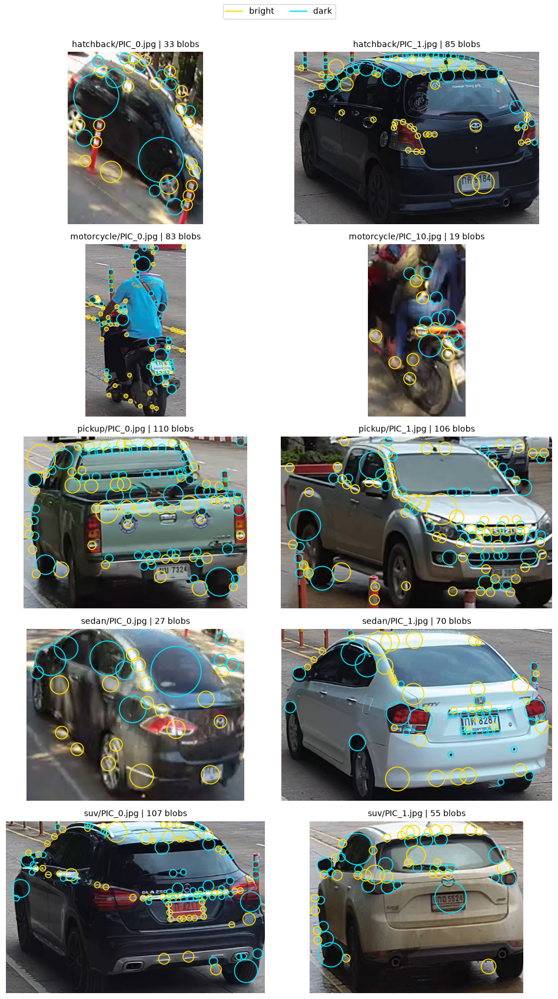

In [10]:
COLORS = {"bright": "#ffdc00", "dark": "#00e5ff"}

def draw_blobs(ax, record, blobs, title, annotate=False):
    ax.imshow(record["rgb"])
    for blob_id, row in enumerate(blobs.itertuples(index=False), start=1):
        color = COLORS[row.polarity]
        ax.add_patch(Circle((row.x_px, row.y_px), row.radius_px, fill=False, color=color, linewidth=1.2))
        if annotate:
            ax.text(row.x_px, row.y_px, str(blob_id), fontsize=6, color=color,
                    bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=0.3))
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-0.5, record["width"] - 0.5)
    ax.set_ylim(record["height"] - 0.5, -0.5)
    ax.axis("off")

fig, axes = plt.subplots(5, 2, figsize=(10, 17))
for ax, (image_id, record) in zip(axes.flat, records.items()):
    blobs = baseline_results[image_id]
    draw_blobs(ax, record, blobs, f"{image_id} | {len(blobs)} blobs")
fig.legend(handles=[Line2D([], [], color=color, label=label) for label, color in COLORS.items()],
           loc="upper center", ncol=2)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(FIGURE_DIR / "02_baseline_detections.png", dpi=140)
plt.show()
plt.close(fig)

for image_id, record in records.items():
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))
    axes[0].imshow(record["rgb"])
    axes[0].set_title("Original (processed display size)")
    axes[0].axis("off")
    draw_blobs(axes[1], record, baseline_results[image_id], image_id, annotate=True)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / (image_id.replace("/", "_").rsplit(".", 1)[0] + "_blobs.png"), dpi=160)
    plt.close(fig)

## 5. Controlled parameter experiments

Change one parameter relative to the baseline at a time, using all ten images:

- **Threshold 0.075 / 0.225:** admit weaker contrast responses or retain only stronger responses.
- **Minimum sigma 7:** exclude small-scale features.
- **Maximum sigma 30:** allow larger regions. With 12 scales fixed, the intermediate sampled scales also
  change; the effect is not only an increased upper radius limit.
- **Overlap 0.2:** suppress overlapping candidates more aggressively.
- **Extra smoothing sigma 2:** reduce fine texture before detection; this can also remove useful details.

The scale-range changes both alter the logarithmic sampling grid. Counts alone are not accuracy scores:
compare the actual circles as well as their number and average size.

setting,baseline,lower threshold,higher threshold,larger minimum,larger maximum,stricter overlap,extra smoothing
image,,,,,,,
hatchback/PIC_0.jpg,33,63,9,12,32,31,15
hatchback/PIC_1.jpg,85,229,27,29,81,76,45
motorcycle/PIC_0.jpg,83,265,20,32,81,78,35
motorcycle/PIC_10.jpg,19,44,6,5,19,18,12
pickup/PIC_0.jpg,110,184,33,38,109,101,61
pickup/PIC_1.jpg,106,191,36,39,104,100,58
sedan/PIC_0.jpg,27,86,7,13,26,25,16
sedan/PIC_1.jpg,70,249,10,36,69,64,39
suv/PIC_0.jpg,107,312,38,40,113,97,49


,total_blobs,mean_radius_px
setting,,
baseline,695,7.48
lower threshold,1734,6.84
higher threshold,207,7.57
larger minimum,277,12.09
larger maximum,687,7.60
stricter overlap,637,7.43
extra smoothing,362,9.34


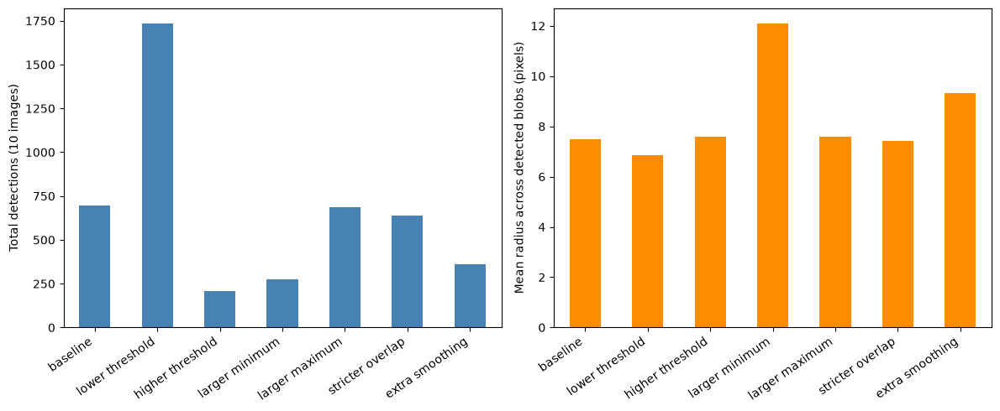

In [11]:
CONFIGS = {
    "baseline": BASELINE,
    "lower threshold": {**BASELINE, "threshold": 0.075},
    "higher threshold": {**BASELINE, "threshold": 0.225},
    "larger minimum": {**BASELINE, "min_sigma": 7.0},
    "larger maximum": {**BASELINE, "max_sigma": 30.0},
    "stricter overlap": {**BASELINE, "overlap": 0.2},
    "extra smoothing": {**BASELINE, "pre_smooth": 2.0},
}
experiment_results = {"baseline": baseline_results}
for name, config in CONFIGS.items():
    if name != "baseline":
        experiment_results[name] = {
            image_id: detect_blobs(record["gray"], **config) for image_id, record in records.items()
        }
experiment_rows = []
for name, results in experiment_results.items():
    for image_id, blobs in results.items():
        experiment_rows.append(dict(setting=name, image=image_id, n_blobs=len(blobs),
                                    mean_radius_px=blobs.radius_px.mean()))
experiments = pd.DataFrame(experiment_rows)
counts = experiments.pivot(index="image", columns="setting", values="n_blobs").reindex(columns=CONFIGS)
display(counts)
aggregate = pd.DataFrame([
    dict(setting=name, total_blobs=sum(len(b) for b in results.values()),
         mean_radius_px=pd.concat(list(results.values()), ignore_index=True).radius_px.mean())
    for name, results in experiment_results.items()
]).set_index("setting")
display(aggregate.round(2))
experiments.to_csv(RESULT_DIR / "parameter_experiments.csv", index=False)
(RESULT_DIR / "experiment_configs.json").write_text(json.dumps(CONFIGS, indent=2), encoding="utf-8")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
aggregate.total_blobs.plot.bar(ax=axes[0], color="steelblue", rot=35)
aggregate.mean_radius_px.plot.bar(ax=axes[1], color="darkorange", rot=35)
axes[0].set_ylabel("Total detections (10 images)")
axes[1].set_ylabel("Mean radius across detected blobs (pixels)")
for ax in axes:
    ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), ha="right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_parameter_summary.png", dpi=150)
plt.show()
plt.close(fig)

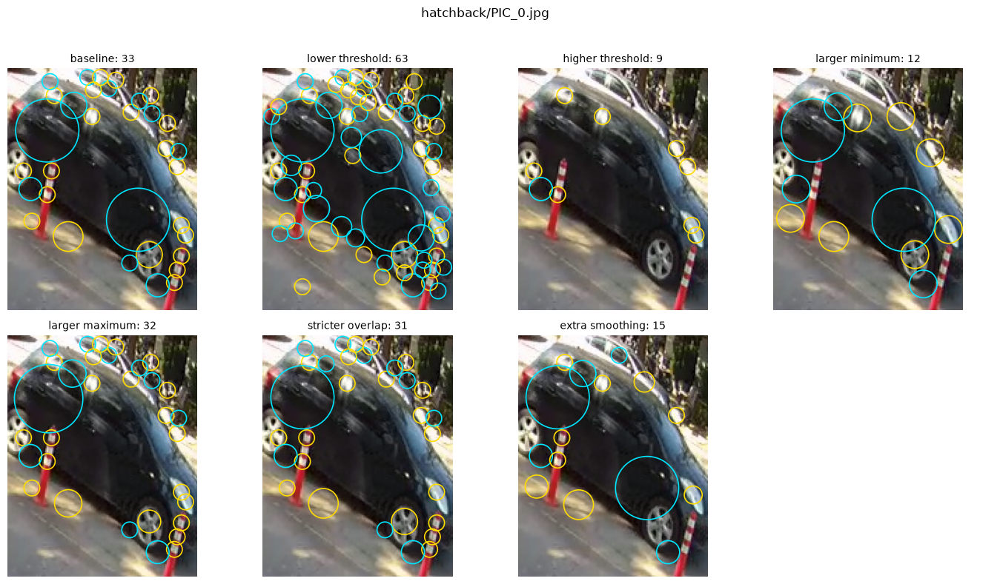

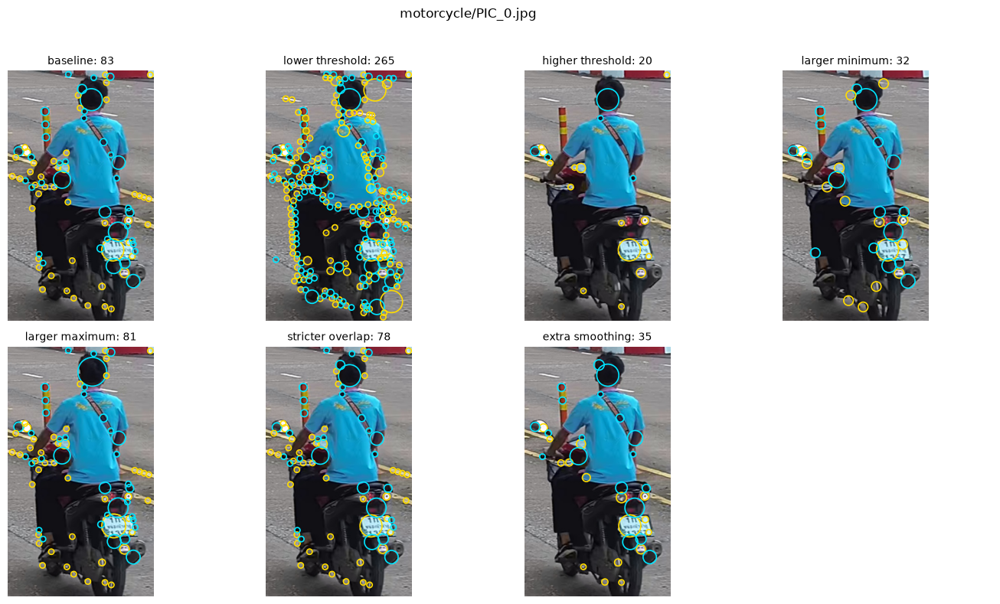

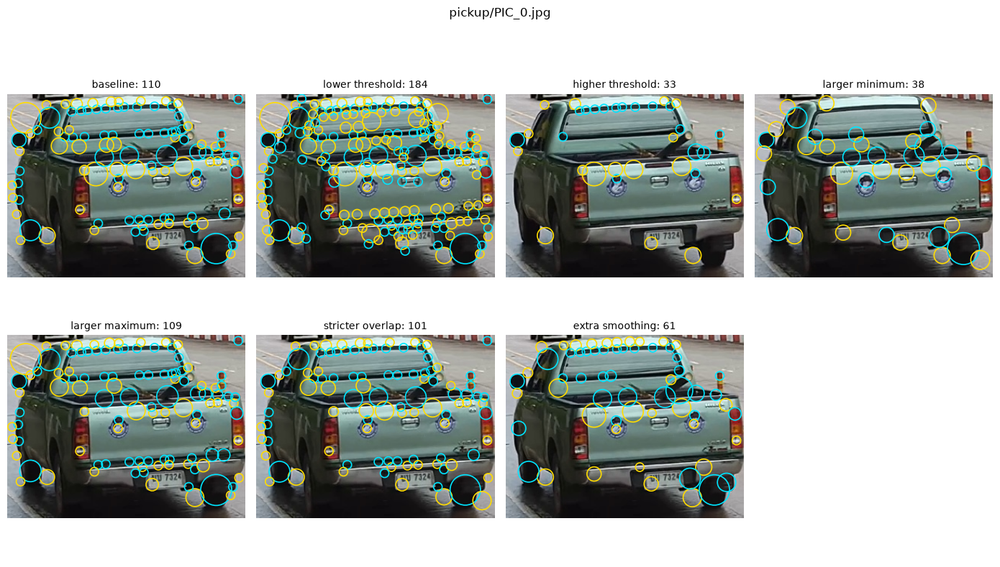

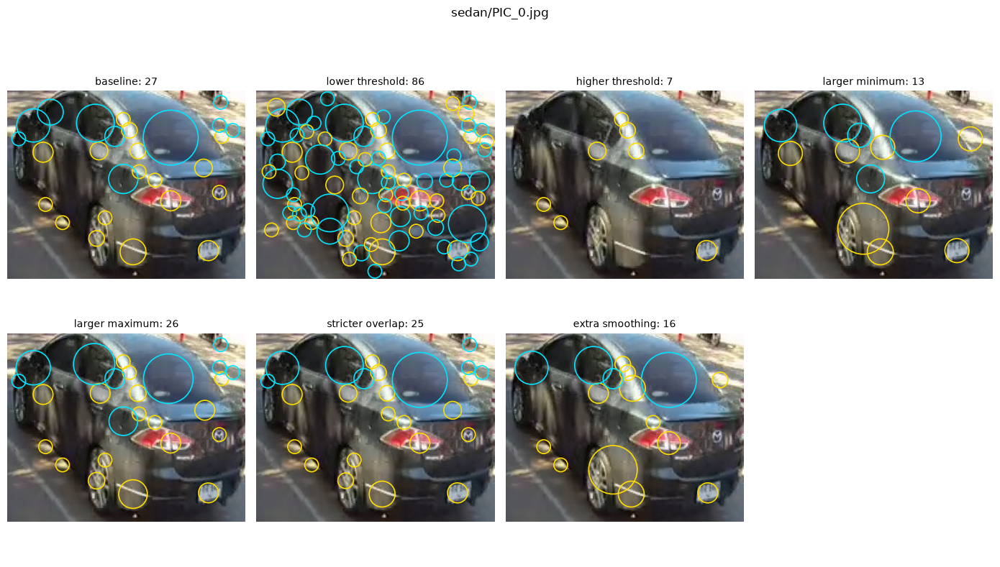

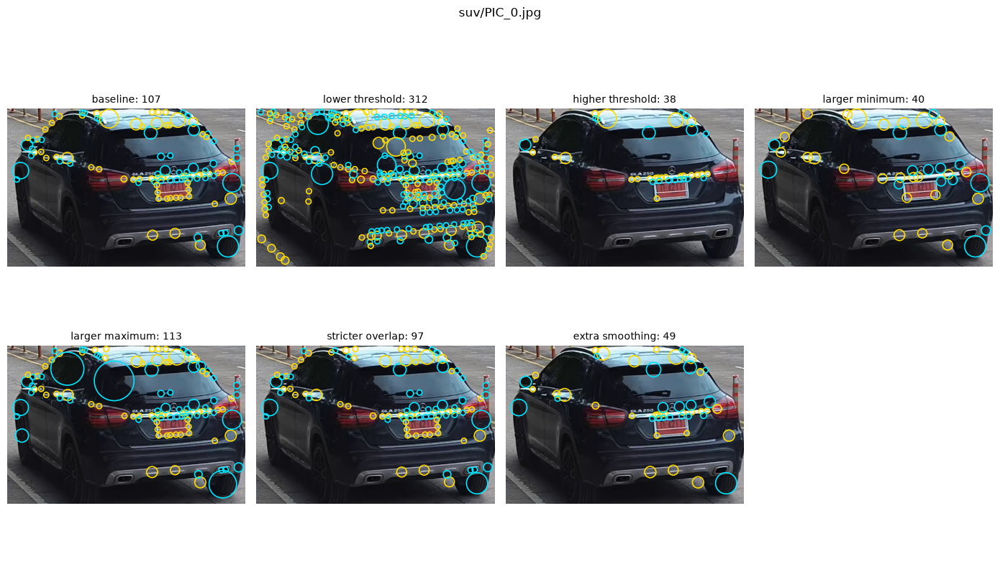

In [12]:
# The first image in each class: same examples for every setting, not cherry-picked by results.
example_ids = list(dict.fromkeys(image_id.split("/")[0] for image_id in image_ids))
example_ids = [next(i for i in image_ids if i.startswith(label + "/")) for label in example_ids]
for image_id in example_ids:
    fig, axes = plt.subplots(2, 4, figsize=(14, 8))
    for ax, name in zip(axes.flat, CONFIGS):
        blobs = experiment_results[name][image_id]
        draw_blobs(ax, records[image_id], blobs, f"{name}: {len(blobs)}")
    axes.flat[-1].axis("off")
    fig.suptitle(image_id)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(FIGURE_DIR / ("parameters_" + image_id.replace("/", "_").rsplit(".", 1)[0] + ".png"), dpi=140)
    plt.show()
    plt.close(fig)

## 6. Results and discussion

The following numerical summary is generated from the current run, so it stays consistent if images
or parameters change. The visual discussion below concerns the supplied fixed sample.

In [13]:
baseline_total = int(aggregate.loc["baseline", "total_blobs"])
lines = [f"Baseline: **{baseline_total} blobs** across {len(records)} images, with a mean estimated radius "
         f"of **{aggregate.loc['baseline', 'mean_radius_px']:.2f} pixels**."]
for name in list(CONFIGS)[1:]:
    row = aggregate.loc[name]
    lines.append(f"- {name.capitalize()}: **{int(row.total_blobs)} blobs** "
                 f"({int(row.total_blobs) - baseline_total:+d} relative to baseline); "
                 f"mean radius **{row.mean_radius_px:.2f} px**.")
display(Markdown("\n\n".join(lines)))

Baseline: **695 blobs** across 10 images, with a mean estimated radius of **7.48 pixels**.

- Lower threshold: **1734 blobs** (+1039 relative to baseline); mean radius **6.84 px**.

- Higher threshold: **207 blobs** (-488 relative to baseline); mean radius **7.57 px**.

- Larger minimum: **277 blobs** (-418 relative to baseline); mean radius **12.09 px**.

- Larger maximum: **687 blobs** (-8 relative to baseline); mean radius **7.60 px**.

- Stricter overlap: **637 blobs** (-58 relative to baseline); mean radius **7.43 px**.

- Extra smoothing: **362 blobs** (-333 relative to baseline); mean radius **9.34 px**.

### Visual findings

The baseline detects 19-110 blobs per image. In `hatchback/PIC_0.jpg`, circles cover wheel regions,
contrasting windows/body patches, road highlights, and red-and-white posts. In `pickup/PIC_0.jpg`,
many small circles follow window trim, the bumper, badges, and the number plate. These edge-related
responses illustrate that LoG does not exclusively detect isolated circular objects. The motorcycle
examples also include clothing, rider features, and roadside details. Thus the detector responds to
local contrast throughout the scene, not just to the labeled vehicle.

The large difference between the two motorcycle images (83 versus 19 baseline detections) should not
be interpreted as a difference in vehicle count. They have different resolution, appearance, and
available detail. Small radii near the minimum allowed scale occur frequently. Such detections may
prefer an even smaller scale outside the search range; similarly, maximum-scale estimates may be
truncated by the upper limit. The circles are scale estimates rather than precise object outlines.

### What the parameter changes show

Lowering the threshold increases the total from 695 to 1,734; raising it decreases the total to 207.
For the pickup example, the corresponding counts are 110, 184, and 33. Lower thresholds add weaker
features around the plate, body, and road, making the result crowded. A higher threshold produces
cleaner overlays but also discards potentially useful low-contrast details. Without blob annotations,
we cannot label either setting as more accurate.

Increasing minimum sigma from 4 to 7 reduces the total to 277 and increases mean radius from 7.48 to
12.09 pixels: small details are intentionally excluded, leaving coarser regions. Increasing maximum
sigma to 30 gives 687 blobs, close to baseline. It does not turn the output into whole-vehicle
regions. Changes in scale sampling, overlap suppression, and the full-circle border rule all affect
this comparison, so increasing the size range need not increase the count.

Stricter overlap suppression reduces the total to 637, removing overlapping alternatives but potentially
merging the representation of neighboring features. Additional smoothing reduces the total to 362
and increases mean radius to 9.34 pixels. In the pickup panel, fewer plate and bumper details survive;
stronger window and body contrasts remain. Smoothing trades fine-detail sensitivity for simpler output.

### Suitability and limitations

This method is useful for finding compact contrast features at different scales without training data.
Both polarities are necessary here because reflective details and dark regions appear together.
However, illumination, perspective, occlusion, image resolution, and clutter affect the response.
Elongated regions are approximated poorly by circles, edge lobes can be retained, and excluding circles
that cross the frame removes partially visible features. Detecting a single coherent vehicle would
require additional segmentation or a semantic object detector; blob counts are not vehicle counts.

The ten-image, filename-selected sample supports qualitative observations only. Baseline parameters
were adjusted on this same sample for readability and are not validated for unseen images. A larger,
more diverse sample with explicit region annotations would be required to compare detection accuracy.
For the upcoming contour comparison, retain the same images and preprocessing, and compare boundary
shape and measured contour area with these circular scale estimates rather than treating the two
methods' region counts or areas as interchangeable.


## References and reproducibility

- [SciPy Gaussian Laplacian](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_laplace.html): Gaussian second derivatives.
- [SciPy maximum filter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.maximum_filter.html): neighborhood maximum operation.
- [scikit-image blob detection example](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_blob.html): LoG background and the approximate 2D radius convention. We implement the detector explicitly rather than calling `blob_log`.

This notebook is deterministic: the manifest and parameter values are fixed and no random sampling is used.
CSV files include all baseline detections and per-image statistics; PNGs include all baseline images and
parameter comparisons for one image per class. The contour notebook remains a separate task and should
reuse this image selection and preprocessing convention for a fair comparison.